# ShotGuide Multi-task Baseline

This notebook builds a baseline model for the shot guide project.

- Input: labeled images under `labeled_dataset/`
- Split: grouped by original video id, parsed from filenames like `0013_cut_006.jpg`
- Model: shared CNN backbone + two heads
- Head 1: `shot_type` = close-up / medium / object / space / wide
- Head 2: `has_text` = notext / text


In [1]:
from pathlib import Path
import json
import random
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedGroupKFold
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = True

ROOT = Path.cwd()
DATA_DIR = ROOT / 'labeled_dataset'
OUTPUT_DIR = ROOT / 'outputs_baseline'
OUTPUT_DIR.mkdir(exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE

C:\Users\user\anaconda3\envs\shotguide-baseline\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device(type='cpu')

## 1. Build Data Index

`unclear` is excluded from baseline training. Keep it for later error analysis or semi-supervised cleanup.

In [2]:
VALID_SHOT_TYPES = ['close-up', 'medium', 'object', 'space', 'wide']
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def parse_folder_label(folder_name: str):
    if folder_name == 'unclear':
        return None
    if folder_name.endswith('_notext'):
        return folder_name[:-7], 0
    if folder_name.endswith('_text'):
        return folder_name[:-5], 1
    return None

def parse_video_id(path: Path):
    match = re.match(r'([^_]+)_cut_\d+', path.stem)
    if match:
        return match.group(1)
    return path.stem.split('_')[0]

rows = []
for class_dir in sorted(DATA_DIR.iterdir()):
    if not class_dir.is_dir():
        continue
    parsed = parse_folder_label(class_dir.name)
    if parsed is None:
        continue
    shot_type, has_text = parsed
    if shot_type not in VALID_SHOT_TYPES:
        continue
    for path in sorted(class_dir.rglob('*')):
        if path.is_file() and path.suffix.lower() in IMAGE_EXTS:
            rows.append({
                'filepath': str(path.resolve()),
                'filename': path.name,
                'video_id': parse_video_id(path),
                'original_class': class_dir.name,
                'shot_type': shot_type,
                'has_text': has_text,
            })

df = pd.DataFrame(rows)
df['joint_label'] = df['shot_type'] + '_' + df['has_text'].map({0: 'notext', 1: 'text'})
df.to_csv(OUTPUT_DIR / 'dataset_index.csv', index=False, encoding='utf-8-sig')

print('images:', len(df))
print('videos:', df['video_id'].nunique())
display(df.head())
display(df['joint_label'].value_counts().sort_index())

images: 1188
videos: 129


,filepath,filename,video_id,original_class,shot_type,has_text,joint_label
0,C:\Temp\deep\labeled_dataset\close-up_notext\0...,0013_cut_006.jpg,0013,close-up_notext,close-up,0,close-up_notext
1,C:\Temp\deep\labeled_dataset\close-up_notext\0...,0013_cut_012.jpg,0013,close-up_notext,close-up,0,close-up_notext
2,C:\Temp\deep\labeled_dataset\close-up_notext\0...,0013_cut_017.jpg,0013,close-up_notext,close-up,0,close-up_notext
3,C:\Temp\deep\labeled_dataset\close-up_notext\0...,0015_cut_001.jpg,0015,close-up_notext,close-up,0,close-up_notext
4,C:\Temp\deep\labeled_dataset\close-up_notext\0...,0024_cut_012.jpg,0024,close-up_notext,close-up,0,close-up_notext


joint_label
close-up_notext     29
close-up_text      118
medium_notext       74
medium_text        331
object_notext       39
object_text        257
space_notext        28
space_text          96
wide_notext         73
wide_text          143
Name: count, dtype: int64

## 2. Video-level Split

All frames/cuts from the same original video id stay in only one split.

In [3]:
def add_grouped_splits(data: pd.DataFrame, seed: int = 42):
    data = data.copy().reset_index(drop=True)
    data['split'] = 'unset'

    sgkf_test = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    train_val_idx, test_idx = next(sgkf_test.split(data, data['joint_label'], groups=data['video_id']))
    data.loc[test_idx, 'split'] = 'test'

    train_val = data.loc[train_val_idx].copy().reset_index()
    sgkf_val = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed + 1)
    train_sub_idx, val_sub_idx = next(sgkf_val.split(train_val, train_val['joint_label'], groups=train_val['video_id']))

    data.loc[train_val.loc[val_sub_idx, 'index'], 'split'] = 'val'
    data.loc[train_val.loc[train_sub_idx, 'index'], 'split'] = 'train'
    return data

df = add_grouped_splits(df, SEED)
df.to_csv(OUTPUT_DIR / 'dataset_index_with_splits.csv', index=False, encoding='utf-8-sig')

display(pd.crosstab(df['joint_label'], df['split']))

leaks = []
for video_id, g in df.groupby('video_id'):
    if g['split'].nunique() > 1:
        leaks.append(video_id)
print('group leakage count:', len(leaks))
assert len(leaks) == 0, leaks[:10]

split,test,train,val
joint_label,,,
close-up_notext,4,24,1
close-up_text,26,76,16
medium_notext,6,45,23
medium_text,79,189,63
object_notext,4,30,5
object_text,58,148,51
space_notext,5,19,4
space_text,22,60,14
wide_notext,23,48,2


group leakage count: 0


## 3. Dataset and Transforms

In [4]:
shot_to_idx = {name: i for i, name in enumerate(VALID_SHOT_TYPES)}
idx_to_shot = {i: name for name, i in shot_to_idx.items()}

train_tfms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.80, 1.0), ratio=(0.85, 1.15)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class ShotGuideDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, transform=None):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image = Image.open(row['filepath']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        shot_label = torch.tensor(shot_to_idx[row['shot_type']], dtype=torch.long)
        text_label = torch.tensor(int(row['has_text']), dtype=torch.long)
        return image, shot_label, text_label

train_df = df[df['split'] == 'train'].copy()
val_df = df[df['split'] == 'val'].copy()
test_df = df[df['split'] == 'test'].copy()

BATCH_SIZE = 32
NUM_WORKERS = 0

train_loader = DataLoader(ShotGuideDataset(train_df, train_tfms), batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(ShotGuideDataset(val_df, eval_tfms), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(ShotGuideDataset(test_df, eval_tfms), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

len(train_df), len(val_df), len(test_df)

(721, 208, 259)

## 4. Multi-task Baseline Model

The backbone is frozen first. This is intentional because the dataset is small.

In [5]:
class MultiTaskResNet18(nn.Module):
    def __init__(self, num_shot_classes: int = 5, pretrained: bool = True, freeze_backbone: bool = True):
        super().__init__()
        if pretrained:
            try:
                weights = models.ResNet18_Weights.DEFAULT
                backbone = models.resnet18(weights=weights)
            except Exception as exc:
                print('Pretrained weights unavailable. Falling back to random init:', exc)
                backbone = models.resnet18(weights=None)
        else:
            backbone = models.resnet18(weights=None)

        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.shot_head = nn.Linear(in_features, num_shot_classes)
        self.text_head = nn.Linear(in_features, 2)

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

    def forward(self, x):
        features = self.backbone(x)
        return self.shot_head(features), self.text_head(features)

model = MultiTaskResNet18(num_shot_classes=len(VALID_SHOT_TYPES), pretrained=True, freeze_backbone=True).to(DEVICE)
sum(p.numel() for p in model.parameters() if p.requires_grad)

3591

## 5. Loss, Optimizer, and Training Loop

In [6]:
def make_class_weights(labels, num_classes):
    counts = Counter(labels)
    total = sum(counts.values())
    weights = [total / (num_classes * max(counts.get(i, 0), 1)) for i in range(num_classes)]
    return torch.tensor(weights, dtype=torch.float32)

shot_train_labels = [shot_to_idx[x] for x in train_df['shot_type']]
text_train_labels = train_df['has_text'].astype(int).tolist()

shot_weights = make_class_weights(shot_train_labels, len(VALID_SHOT_TYPES)).to(DEVICE)
text_weights = make_class_weights(text_train_labels, 2).to(DEVICE)

shot_criterion = nn.CrossEntropyLoss(weight=shot_weights)
text_criterion = nn.CrossEntropyLoss(weight=text_weights)
optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=1e-3, weight_decay=1e-4)

TEXT_LOSS_WEIGHT = 1.0
EPOCHS = 3

def run_epoch(model, loader, train: bool):
    model.train(train)
    total_loss = 0.0
    all_shot_true, all_shot_pred = [], []
    all_text_true, all_text_pred = [], []

    pbar = tqdm(loader, leave=False)
    for images, shot_labels, text_labels in pbar:
        images = images.to(DEVICE)
        shot_labels = shot_labels.to(DEVICE)
        text_labels = text_labels.to(DEVICE)

        with torch.set_grad_enabled(train):
            shot_logits, text_logits = model(images)
            loss = shot_criterion(shot_logits, shot_labels) + TEXT_LOSS_WEIGHT * text_criterion(text_logits, text_labels)
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * images.size(0)
        all_shot_true.extend(shot_labels.cpu().numpy().tolist())
        all_shot_pred.extend(shot_logits.argmax(1).cpu().numpy().tolist())
        all_text_true.extend(text_labels.cpu().numpy().tolist())
        all_text_pred.extend(text_logits.argmax(1).cpu().numpy().tolist())

    metrics = {
        'loss': total_loss / len(loader.dataset),
        'shot_acc': accuracy_score(all_shot_true, all_shot_pred),
        'shot_macro_f1': f1_score(all_shot_true, all_shot_pred, average='macro', zero_division=0),
        'text_acc': accuracy_score(all_text_true, all_text_pred),
        'text_f1': f1_score(all_text_true, all_text_pred, average='binary', zero_division=0),
        'joint_acc': np.mean((np.array(all_shot_true) == np.array(all_shot_pred)) & (np.array(all_text_true) == np.array(all_text_pred))),
    }
    return metrics

history = []
best_val_joint = -1.0
best_path = OUTPUT_DIR / 'best_multitask_resnet18_final.pt'
best_state = None

for epoch in range(1, EPOCHS + 1):
    train_metrics = run_epoch(model, train_loader, train=True)
    val_metrics = run_epoch(model, val_loader, train=False)
    row = {'epoch': epoch, **{f'train_{k}': v for k, v in train_metrics.items()}, **{f'val_{k}': v for k, v in val_metrics.items()}}
    history.append(row)
    print(row)
    if val_metrics['joint_acc'] > best_val_joint:
        best_val_joint = val_metrics['joint_acc']
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

torch.save({'model_state_dict': best_state, 'shot_to_idx': shot_to_idx, 'idx_to_shot': idx_to_shot}, best_path)
history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / 'training_history.csv', index=False)
history_df

  0%|          | 0/23 [00:00<?, ?it/s]

  4%|▍         | 1/23 [00:01<00:22,  1.01s/it]

  9%|▊         | 2/23 [00:01<00:20,  1.00it/s]

 13%|█▎        | 3/23 [00:02<00:19,  1.02it/s]

 17%|█▋        | 4/23 [00:03<00:18,  1.03it/s]

...

 71%|███████▏  | 5/7 [00:03<00:01,  1.54it/s]

 86%|████████▌ | 6/7 [00:03<00:00,  1.54it/s]

100%|██████████| 7/7 [00:04<00:00,  1.85it/s]

{'epoch': 3, 'train_loss': 1.3806991656511072, 'train_shot_acc': 0.7128987517337032, 'train_shot_macro_f1': 0.707699872841738, 'train_text_acc': 0.7780859916782247, 'train_text_f1': 0.84375, 'train_joint_acc': np.float64(0.5617198335644937), 'val_loss': 1.7141316854036772, 'val_shot_acc': 0.5817307692307693, 'val_shot_macro_f1': 0.5742681447279938, 'val_text_acc': 0.6009615384615384, 'val_text_f1': 0.7167235494880546, 'val_joint_acc': np.float64(0.36538461538461536)}


,epoch,train_loss,train_shot_acc,train_shot_macro_f1,train_text_acc,train_text_f1,train_joint_acc,val_loss,val_shot_acc,val_shot_macro_f1,val_text_acc,val_text_f1,val_joint_acc
0,1,2.195876,0.350902,0.341945,0.635229,0.740375,0.226075,1.919164,0.562500,0.412222,0.552885,0.671378,0.322115
1,2,1.632117,0.622746,0.601553,0.747573,0.823643,0.450763,1.841041,0.500000,0.496913,0.538462,0.652174,0.293269
2,3,1.380699,0.712899,0.707700,0.778086,0.843750,0.561720,1.714132,0.581731,0.574268,0.600962,0.716724,0.365385


## 6. Test Evaluation

In [7]:
checkpoint = torch.load(best_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

shot_true, shot_pred = [], []
text_true, text_pred = [], []
shot_probs, text_probs = [], []

with torch.no_grad():
    for images, shot_labels, text_labels in tqdm(test_loader):
        images = images.to(DEVICE)
        shot_logits, text_logits = model(images)
        shot_prob = torch.softmax(shot_logits, dim=1)
        text_prob = torch.softmax(text_logits, dim=1)

        shot_true.extend(shot_labels.numpy().tolist())
        text_true.extend(text_labels.numpy().tolist())
        shot_pred.extend(shot_prob.argmax(1).cpu().numpy().tolist())
        text_pred.extend(text_prob.argmax(1).cpu().numpy().tolist())
        shot_probs.extend(shot_prob.max(1).values.cpu().numpy().tolist())
        text_probs.extend(text_prob[:, 1].cpu().numpy().tolist())

test_metrics = {
    'shot_acc': accuracy_score(shot_true, shot_pred),
    'shot_macro_f1': f1_score(shot_true, shot_pred, average='macro', zero_division=0),
    'text_acc': accuracy_score(text_true, text_pred),
    'text_f1': f1_score(text_true, text_pred, average='binary', zero_division=0),
    'joint_acc': np.mean((np.array(shot_true) == np.array(shot_pred)) & (np.array(text_true) == np.array(text_pred))),
}
print(json.dumps(test_metrics, indent=2))

print('\nShot type report')
print(classification_report(shot_true, shot_pred, target_names=VALID_SHOT_TYPES, zero_division=0))
print('\nText report')
print(classification_report(text_true, text_pred, target_names=['notext', 'text'], zero_division=0))

  0%|          | 0/9 [00:00<?, ?it/s]

 11%|█         | 1/9 [00:00<00:04,  1.61it/s]

 22%|██▏       | 2/9 [00:01<00:04,  1.50it/s]

 33%|███▎      | 3/9 [00:02<00:04,  1.46it/s]

 44%|████▍     | 4/9 [00:02<00:03,  1.43it/s]

...

 67%|██████▋   | 6/9 [00:04<00:02,  1.41it/s]

 78%|███████▊  | 7/9 [00:04<00:01,  1.40it/s]

 89%|████████▉ | 8/9 [00:05<00:00,  1.41it/s]

100%|██████████| 9/9 [00:05<00:00,  1.58it/s]

{
  "shot_acc": 0.7104247104247104,
  "shot_macro_f1": 0.7071751112269045,
  "text_acc": 0.6602316602316602,
  "text_f1": 0.7621621621621621,
  "joint_acc": 0.4980694980694981
}

Shot type report
              precision    recall  f1-score   support

    close-up       0.69      0.73      0.71        30
      medium       0.85      0.62      0.72        85
      object       0.70      0.77      0.73        62
       space       0.62      0.78      0.69        27
        wide       0.65      0.73      0.68        55

    accuracy                           0.71       259
   macro avg       0.70      0.73      0.71       259
weighted avg       0.73      0.71      0.71       259


Text report
              precision    recall  f1-score   support

      notext       0.28      0.71      0.41        42
        text       0.92      0.65      0.76       217

    accuracy                           0.66       259
   macro avg       0.60      0.68      0.58       259
weighted avg       0.82      0

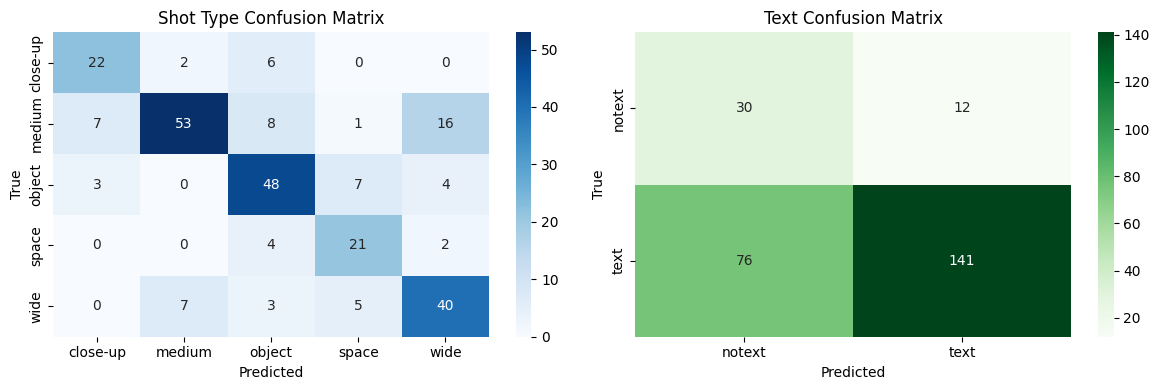

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

shot_cm = confusion_matrix(shot_true, shot_pred, labels=list(range(len(VALID_SHOT_TYPES))))
sns.heatmap(shot_cm, annot=True, fmt='d', cmap='Blues', xticklabels=VALID_SHOT_TYPES, yticklabels=VALID_SHOT_TYPES, ax=axes[0])
axes[0].set_title('Shot Type Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

text_cm = confusion_matrix(text_true, text_pred, labels=[0, 1])
sns.heatmap(text_cm, annot=True, fmt='d', cmap='Greens', xticklabels=['notext', 'text'], yticklabels=['notext', 'text'], ax=axes[1])
axes[1].set_title('Text Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrices.png', dpi=160)
plt.show()

In [9]:
result_df = test_df.copy().reset_index(drop=True)
result_df['pred_shot_type'] = [idx_to_shot[i] for i in shot_pred]
result_df['pred_has_text'] = text_pred
result_df['shot_confidence'] = shot_probs
result_df['text_probability'] = text_probs
result_df['shot_correct'] = result_df['shot_type'] == result_df['pred_shot_type']
result_df['text_correct'] = result_df['has_text'].astype(int) == result_df['pred_has_text']
result_df['joint_correct'] = result_df['shot_correct'] & result_df['text_correct']
result_df.to_csv(OUTPUT_DIR / 'test_predictions.csv', index=False, encoding='utf-8-sig')

display(result_df[['filename', 'video_id', 'shot_type', 'pred_shot_type', 'has_text', 'pred_has_text', 'shot_confidence', 'text_probability', 'joint_correct']].head(20))

,filename,video_id,shot_type,pred_shot_type,has_text,pred_has_text,shot_confidence,text_probability,joint_correct
0,0037_cut_002.jpg,0037,close-up,close-up,0,0,0.537417,0.464296,True
1,0048_cut_027.jpg,0048,close-up,close-up,0,1,0.557839,0.708684,False
2,0114_cut_001.jpg,0114,close-up,close-up,0,1,0.677822,0.557094,False
3,0114_cut_015.jpg,0114,close-up,close-up,0,0,0.408230,0.440681,True
4,0019_cut_002.jpg,0019,close-up,close-up,1,1,0.448355,0.570389,True
5,0025_cut_011.jpg,0025,close-up,close-up,1,0,0.852453,0.248913,False
6,0048_cut_017.jpg,0048,close-up,close-up,1,1,0.667152,0.750942,True
7,0048_cut_019.jpg,0048,close-up,close-up,1,1,0.485447,0.687867,True
8,0048_cut_021.jpg,0048,close-up,close-up,1,1,0.523008,0.592510,True
9,0048_cut_022.jpg,0048,close-up,close-up,1,1,0.700927,0.600519,True
